# 📘 Домашнє завдання 25. Введення в Agentic AI

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW25


## Мета

Створити агента на базі LangGraph, який відповідає на запитання про історію машинного навчання, використовуючи RAG (Retrieval-Augmented Generation).

### Джерело знань

Стаття:

https://arxiv.org/pdf/2408.01747.pdf

**Classical Machine Learning: Seventy Years of Algorithmic Learning Evolution**

---

## Що повинен робити агент?

Користувач ставить запитання:

```text
What are the main milestones in machine learning?
```

або

```text
Which algorithms were influential in the 1990s?
```

Агент:

1. Отримує питання.
2. Шукає релевантні фрагменти статті.
3. Передає знайдений контекст до LLM.
4. Генерує відповідь на основі контексту.

---

## Архітектура

```text
START
  ↓
Retrieve Documents
  ↓
Generate Answer
  ↓
END
```

---

## Використати

### LLM

```python
Qwen/Qwen2.5-1.5B-Instruct
```

### Embeddings

```python
sentence-transformers/all-MiniLM-L6-v2
```

---

## Встановлення

```bash
pip install \
langgraph \
langchain \
langchain-community \
sentence-transformers \
faiss-cpu \
pypdf \
transformers \
torch
```

---


# Частина 1. State

```python
from typing import TypedDict

class RAGState(TypedDict):
    """
    Стан агента.
    """

    question: str

    context: str

    answer: str
```

---

# Частина 2. Завантаження PDF

```python
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader(
    "2408.01747.pdf"
)

documents = loader.load()
```

---

# Частина 3. Розбиття на чанки

Заповніть пропуски.

```python
from langchain.text_splitter import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=__________,
    chunk_overlap=__________
)

chunks = splitter.split_documents(
    documents
)
```

---

# Частина 4. Створення ембедінгів

```python
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)
```

---

# Частина 5. Створення векторної бази

Заповніть один пропуск.

```python
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    chunks,
    __________
)
```

---

# Частина 6. Retriever

```python
retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 3
    }
)
```

---

# Частина 7. Ініціалізація Qwen

```python
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    max_new_tokens=300
)
```

---

# Частина 8. Функція виклику LLM

Заповніть один пропуск.

```python
def ask_llm(prompt: str):

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    response = llm(
        __________,
        return_full_text=False
    )

    return response[0]["generated_text"]
```

---

# Частина 9. Node 1 — Retrieval

Заповніть пропуски.

```python
def retrieve_documents(state: RAGState):
    """
    Пошук релевантних фрагментів статті.
    """

    docs = retriever.invoke(
        __________
    )

    context = "\n\n".join(
        [
            d.page_content
            for d in docs
        ]
    )

    return {
        "context": context
    }
```

---

# Частина 10. Node 2 — Answer Generation

Заповніть один пропуск.

```python
def generate_answer(state: RAGState):
    """
    Генерує відповідь на основі
    знайдених фрагментів статті.
    """

    prompt = f"""
Answer the question using ONLY the context.

Question:
{state['question']}

Context:
{state['context']}
"""

    answer = __________(prompt)

    return {
        "answer": answer
    }
```

---

# Частина 11. Побудова графа

Заповніть пропуски.

```python
from langgraph.graph import (
    StateGraph,
    START,
    END
)

builder = StateGraph(RAGState)

builder.add_node(
    "retrieve",
    retrieve_documents
)

builder.add_node(
    "answer",
    generate_answer
)

builder.add_edge(
    START,
    __________
)

builder.add_edge(
    __________,
    __________
)

builder.add_edge(
    __________,
    END
)

graph = builder.compile()
```

---

# Частина 12. Запуск

```python
result = graph.invoke(
    {
        "question":
        "What are the major milestones in machine learning?"
    }
)

print(result["answer"])
```

### Очікувана архітектура

```text
START
  ↓
Rewrite Question
  ↓
Retrieve Documents
  ↓
Generate Answer
  ↓
END
```


In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
    "kagglehub",
    "kagglesdk",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "kagglehub[pandas-datasets]",
    "numpy",
    "matplotlib",
    "scipy",
    "statsmodels",
    "joblib",
    "torch",
    "transformers",
    "pypdf",
    "unstructured",
    "unstructured[pdf]",
    "langchain-unstructured",
    "langchain_text_splitters",
    "langchain_huggingface",
    "sentence_transformers",
    "chromadb",
    "langchain-chroma",
    "langchain_unstructured",
    "sentencepiece",
    "sacremoses",
    "langgraph",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input data
hm_version = 25

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone data
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

# ✅ Крок: Частина 1. State

In [3]:
# State

from typing_extensions import TypedDict


# Input data

# Solution
class RAGState(TypedDict):
    """
    Стан агента
    """
    question: str
    question_ua: str
    context: str
    answer: str
    answer_ua: str

# Print results


# ✅ Крок: Частина 2. Завантаження PDF

In [4]:
# Load document

import requests
import apps.reporter as rpt
from pathlib import Path
from langchain_unstructured.document_loaders import UnstructuredLoader

# Input data
df_file_name = "Файл: Classical Machine Learning"
load_file = True
file_name = "resources/сlassical_machine_learning.pdf"
file_url = "https://arxiv.org/pdf/2408.01747.pdf"

# Solution
file_path = Path(file_name)

# try to load file
if load_file and file_path.exists():
    loader = UnstructuredLoader(file_path, strategy="fast", languages=["ukr"])
else:
    site_response = requests.get(file_url, stream=True)
    # save file
    if site_response.status_code == 200:
        with open(file_path, "wb") as current_file:
            current_file.write(site_response.content)
    loader = UnstructuredLoader(file_path, strategy="fast", languages=["ukr"])

docs = loader.load()

rp = rpt.Reporter()
rp.add_item("Розмір документа", str(len(docs)))

# Print results
rp.print_pd_report(df_file_name)

INFO: pikepdf C++ to Python logger bridge initialized


Attribute,Result
Розмір документа,927


# ✅ Крок: Частина 3. Розбиття на чанки

In [5]:
# Splitting data

import apps.reporter as rpt
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Input data

# Solution
# обʼєднуємо дані попередньо розбиті
full_text = "\n\n".join([doc.page_content for doc in docs])

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150
)

# розбиваємо на чанки
chunks = splitter.split_text(full_text)

rp = rpt.Reporter()
rp.add_item("Кількість чанків", str(len(chunks)))

# Print results
rp.print_pd_report(df_file_name)


Attribute,Result
Кількість чанків,208


# ✅ Крок: Частина 4. Створення ембедінгів

In [6]:
# Embeddings

import torch
from pathlib import Path
from sentence_transformers import SentenceTransformer
from langchain_huggingface import HuggingFaceEmbeddings

# Input data
load_model = True
model_file_name = "resources/embedding_model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    embeddings = HuggingFaceEmbeddings(
        model_name=str(file_path),
        encode_kwargs={'prompt_name': 'document'},
        model_kwargs={"local_files_only": True},
    )
else:
    model = SentenceTransformer("intfloat/multilingual-e5-base")
    # save model
    model.save(str(file_path))

    embeddings = HuggingFaceEmbeddings(
        model_name=str(file_path),
        encode_kwargs={'prompt_name': 'document'},
        model_kwargs={"local_files_only": True},
    )

# Print results


INFO: No device provided, using mps
INFO: Loading SentenceTransformer model from resources/embedding_model.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

# ✅ Крок: Частина 5. Створення векторної бази

In [7]:
# Vectors storage

import torch
from langchain_chroma import Chroma

# Input data

# Solution
db_vectors = Chroma.from_texts(
    texts=chunks,
    embedding=embeddings
)

# Print results


# ✅ Крок: Частина 6. Retriever

In [8]:
# Retriever

import torch

# Input data
n_docs = 5

# Solution
retriever = db_vectors.as_retriever(
    search_type="similarity",
    search_kwargs={"k": n_docs}
)

# Print results


# ✅ Крок: Частина 7. Ініціалізація Qwen

In [9]:
# LLM model

import torch
from pathlib import Path
from transformers import pipeline

# Input data
load_model = True
model_file_name = "resources/instruction_understanding_model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = pipeline(
        "text-generation",
        model=model_file_name,
        tokenizer=model_file_name,
        clean_up_tokenization_spaces=False,
    )
else:
    model = pipeline(
        "text-generation",
        model="Qwen/Qwen2.5-1.5B-Instruct",
        # model="Qwen/Qwen2.5-7B-Instruct",
        clean_up_tokenization_spaces=False,
    )
    # save model
    model.model.save_pretrained(model_file_name)
    model.tokenizer.save_pretrained(model_file_name)

llm_model = model

# Print results


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [10]:
# Translate model UA -> EN

import torch
import apps.reporter as rpt
from pathlib import Path
from transformers import MarianTokenizer, AutoModelForSeq2SeqLM

# Input data
query_ua = "Які основні прориви відбулися в машинному навчанні?"

load_model = True
model_file_name = "resources/translation_ua_2_en_model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    tokenizer = MarianTokenizer.from_pretrained(
        model_file_name,
        clean_up_tokenization_spaces=False
    )
    model = AutoModelForSeq2SeqLM.from_pretrained(model_file_name)
else:
    tokenizer = MarianTokenizer.from_pretrained(
        "Helsinki-NLP/opus-mt-uk-en",
        clean_up_tokenization_spaces=False
    )
    model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-uk-en")
    # save model
    tokenizer.save_pretrained(model_file_name)
    model.save_pretrained(model_file_name)

ua_2_en_model = model
ua_2_en_tokenizer = tokenizer


def translate_ua_2_en(text: str) -> str:
    inputs = ua_2_en_tokenizer(text, return_tensors="pt", padding=True)
    translated_tokens = ua_2_en_model.generate(**inputs)
    result = ua_2_en_tokenizer.decode(translated_tokens, skip_special_tokens=True)
    return " ".join(result)


rp = rpt.Reporter("UA", "EN")
rp.add_item(query_ua, translate_ua_2_en(query_ua))

# Print results
rp.print_pd_report("Тестування перекладу із UA на EN")

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

UA,EN
Які основні прориви відбулися в машинному навчанні?,What are some of the basic breakthroughs in machine learning?


In [11]:
# Translate model EN -> UA

import torch
import apps.reporter as rpt
from pathlib import Path
from transformers import MarianTokenizer, AutoModelForSeq2SeqLM

# Input data
query_en = "What are the main milestones in machine learning?"

load_model = True
model_file_name = "resources/translation_en_2_ua_model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    tokenizer = MarianTokenizer.from_pretrained(
        model_file_name,
        clean_up_tokenization_spaces=False
    )
    model = AutoModelForSeq2SeqLM.from_pretrained(model_file_name)
else:
    tokenizer = MarianTokenizer.from_pretrained(
        "Helsinki-NLP/opus-mt-en-uk",
        clean_up_tokenization_spaces=False
    )
    model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-uk")
    # save model
    tokenizer.save_pretrained(model_file_name)
    model.save_pretrained(model_file_name)

en_2_ua_model = model
en_2_ua_tokenizer = tokenizer


def translate_en_2_ua(text: str) -> str:
    inputs = en_2_ua_tokenizer(text, return_tensors="pt", padding=True)
    translated_tokens = en_2_ua_model.generate(**inputs)
    result = en_2_ua_tokenizer.decode(translated_tokens, skip_special_tokens=True)
    return " ".join(result)


rp = rpt.Reporter("EN", "UA")
rp.add_item(query_en, translate_en_2_ua(query_en))

# Print results
rp.print_pd_report("Тестування перекладу з EN на UA")

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

EN,UA
What are the main milestones in machine learning?,Які головні етапи навчання машин?


# ✅ Крок: Частина 8. Функція виклику LLM

In [12]:
# Call LLM

import torch
from transformers import GenerationConfig


# Input data

# Solution
def ask_llm(prompt: str) -> str:
    config = GenerationConfig(
        max_new_tokens=300,
        temperature=None,
        top_p=None,
        top_k=None,
        pad_token_id=llm_model.tokenizer.eos_token_id
    )
    messages = [{
        "role": "user",
        "content": prompt
    }]
    response = llm_model(messages,
                         generation_config=config,
                         return_full_text=False)
    return response[0]["generated_text"].strip()  # type: ignore

# Print results


# ✅ Крок: Частина 9. Node 1 — Retrieval

In [13]:
# Node 1 - Retrieval

# Input data

# Solution
def retrieve_documents(state: RAGState):
    """
    Пошук релевантних фрагментів статті.
    """
    docs = retriever.invoke(state["question"])
    context = "\n\n".join([d.page_content for d in docs])
    return {"context": context}

# Print results


# ✅ Крок: Частина 10. Node 2 — Answer Generation

In [14]:
# Node 2 - Answer Generation

# Input data

# Solution
def generate_answer(state: RAGState):
    """
    Генерує відповідь на основі знайдених фрагментів статті.
    """
    prompt = f"""
Answer the question using ONLY the context.

Question:
{state['question']}

Context:
{state['context']}
"""

    answer = ask_llm(prompt)
    return {"answer": answer}

# Print results


In [15]:
# Node 3 and 4 - Translation UA -> EN and EN -> UA

# Input data

# Solution
def translation_query_ua_2_en(state: RAGState):
    """
    Переклад запиту з української на англійську
    """
    translation = translate_ua_2_en(state["question_ua"])
    return {"question": translation}


def translation_query_en_2_ua(state: RAGState):
    """
    Переклад запиту з англійської на українську
    """
    translation = translate_en_2_ua(state["question"])
    return {"question_ua": translation}


def translation_answer_en_2_ua(state: RAGState):
    """
    Переклад відповіді з англійської на українську
    """
    translation = translate_en_2_ua(state["answer"])
    return {"answer_ua": translation}


def decide_translation_node(state: RAGState) -> str | None:
    """
    Вибір шляху для перекладу
    """
    if state.get("question_ua") is None:
        return "query_en_2_ua_node"
    elif state.get("question") is None:
        return "query_ua_2_en_node"
    else:
        return "retrieve_node"

# Print results


# ✅ Крок: Частина 11. Побудова графа

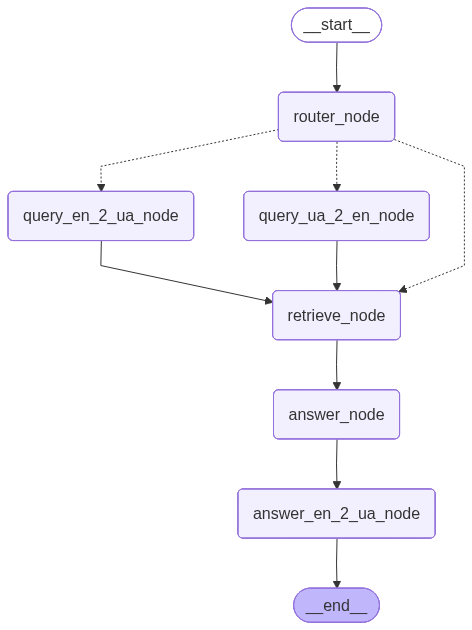

In [16]:
# Build Graph

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Input data

# Solution
builder = StateGraph(RAGState)  # type: ignore

# додаємо nodes
builder.add_node("router_node", lambda state: state)  # passthrough function
builder.add_node("retrieve_node", retrieve_documents)  # type: ignore
builder.add_node("answer_node", generate_answer)  # type: ignore
builder.add_node("query_en_2_ua_node", translation_query_en_2_ua)  # type: ignore
builder.add_node("query_ua_2_en_node", translation_query_ua_2_en)  # type: ignore
builder.add_node("answer_en_2_ua_node", translation_answer_en_2_ua)  # type: ignore

# задаємо шляхи
builder.add_edge(START, "router_node")
builder.add_conditional_edges("router_node", decide_translation_node,
                              {
                                  "query_en_2_ua_node": "query_en_2_ua_node",
                                  "query_ua_2_en_node": "query_ua_2_en_node",
                                  "retrieve_node": "retrieve_node"
                              })
builder.add_edge("query_en_2_ua_node", "retrieve_node")
builder.add_edge("query_ua_2_en_node", "retrieve_node")
builder.add_edge("retrieve_node", "answer_node")
builder.add_edge("answer_node", "answer_en_2_ua_node")
builder.add_edge("answer_en_2_ua_node", END)

# компіляція
graph = builder.compile()

# Print results

display(Image(graph.get_graph().draw_mermaid_png()))

# ✅ Крок: Частина 12. Запуск

In [21]:
# Execution

import apps.reporter as rpt

# Input data
questions = {
    "en-1": "What are the main milestones in machine learning?",
    "ua-1": "Які основні прориви відбулися в машинному навчанні?",
    "en-2": "Which algorithms were influential in the 1990s?",
    "ua-2": "Які алгоритми мали найбільший вплив у 1990-х роках?",
}

# Solution
for lang, question in questions.items():
    rp = rpt.Reporter("Запитання", "Відповідь")

    if "ua" in lang:
        result = graph.invoke({
            "question_ua": question,
            "question": None,
            "context": "",
            "answer": "",
            "answer_ua": ""
        })
        rp.add_item("Оригінальне запитання", question)
        rp.add_item("Переклад запитання", result["question"])
        rp.add_item("Відповідь українською", result["answer_ua"])
        rp.add_item("Відповідь англійською", result["answer"])

        # Print results
        rp.print_pd_report(f"Результати роботи агента для {lang}")
    else:
        result = graph.invoke({
            "question": question,
            "question_ua": None,
            "context": "",
            "answer": "",
            "answer_ua": ""
        })
        rp.add_item("Оригінальне запитання", question)
        rp.add_item("Переклад запитання", result["question_ua"])
        rp.add_item("Відповідь англійською", result["answer"])
        rp.add_item("Відповідь українською", result["answer_ua"])

        # Print results
        rp.print_pd_report(f"Результати роботи агента для {lang}")


Запитання,Відповідь
Оригінальне запитання,What are the main milestones in machine learning?
Переклад запитання,Які головні етапи навчання машин?
Відповідь англійською,"The main milestones in machine learning include: 1. **Perceptron Model (Frank Rosenblatt, 1957)** - An early type of neural network capable of learning to classify input patterns. 2. **Turing Test** - Proposed by Alan Turing in his seminal paper ""Computing Machinery and Intelligence,"" providing a benchmark for AI. 3. **Arthur Samuel's Checkers Playing Program (1952)** - Developed to improve its performance over time through a process of learning from experience. These milestones represent significant advancements in the foundational concepts and methodologies of machine learning."
Відповідь українською,"Основні етапи навчання машин: 1. **Percoperon Модель (Frank Rosenblatt, 1957) * - ранній тип нейронної мережі, що здатна навчитися класифікувати шаблони вхідних даних. 2. ** * * * - Запропонована Аланом Тюверінгом у своїй напіврядковій газеті ""Скомпонування комп' ютерів і розвідки,"" що забезпечує значки ШІ. 3. **Artur Samuel's Charching Program (1952) * - розроблена для покращення своєї швидкодії через процес навчання з досвіду. Ці етапи є значними досягненнями у базових концептах та методах навчання комп' ютерів."


Запитання,Відповідь
Оригінальне запитання,Які основні прориви відбулися в машинному навчанні?
Переклад запитання,What are some of the basic breakthroughs in machine learning?
Відповідь українською,"Серед базових проривів у навчанні машин: 1. **Percepetron * *: Розроблено Франком Розенблатом у 1957 році, цей алгоритм створює основу для багатьох сучасних архітектур нейронної мережі. 2. ***** ...Зроблено подібною до дерева структурою Лео Бреймана у 2001 році, ці алгоритми поєднують багато рішень для покращення точності та контролю над прогнозуванням. 3. ** Дисципліти *: Застосовані Россом Kinlan у 1986 р., ці моделі використовують деревоподібну структуру для створення прогнозів на основі значень можливостей. 4. ** LOMLPar Regression *: Запропонований Рональдом Фішером у 1926 році, цей метод використовується для прогнозування нескінченних результатів на основі незалежних змінних. ** * * ...Греакторичний перехід *: Створив Девіда і сера. Кокс, цю техніку використовують для класифікації завдань, що залежать від змінних або дифокусових компенсацій. Особливо високо-сифіксові та кривих (ширенсій) з синусій та високосійними системами CMPse * та SXMP."
Відповідь англійською,"Some of the basic breakthroughs in machine learning include: 1. **Perceptron**: Developed by Frank Rosenblatt in 1957, this algorithm forms the basis for many modern neural network architectures. 2. **Random Forests**: Introduced by Leo Breiman in 2001, these algorithms combine multiple decision trees to improve prediction accuracy and control overfitting. 3. **Decision Trees**: Proposed by Ross Quinlan in 1986, these models use a tree-like structure to make predictions based on feature values. 4. **Linear Regression**: Invented by Ronald Fisher in 1926, this method is used for predicting continuous outcomes based on a set of independent variables. 5. **Logistic Regression**: Created by David Cox and Sir David R. Cox in 1958, this technique is used for binary classification tasks where the dependent variable can be categorical or dichotomous. 6. **Support Vector Machines (SVM)**: Introduced by Vladimir Vapnik in 1995, SVMs are powerful tools for classification and regression tasks, particularly when dealing with high-dimensional data. These algorithms form the cornerstone of classical machine learning and have been pivotal in advancing various technological domains and scientific discoveries."


Запитання,Відповідь
Оригінальне запитання,Which algorithms were influential in the 1990s?
Переклад запитання,Які алгоритми мали вплив у 1990-х роках?
Відповідь англійською,"The algorithms mentioned in the given text include: - Inductive Generalization - Neural Networks - Randomness - Decision Trees - Ensemble Methods These algorithms were influential in the 1990s according to the passage, laying important groundwork for state-of-the-art ML algorithms."
Відповідь українською,"Алгоритми, згадані у даному тексті, включають: - Індуктивне узагальнення - Невербальна мережа - випадковість - Дерева-прийнятливі способи - Ці алгоритми впливали у 1990-х, відповідно до проходу, закладаючи важливу основу для сучасних алгоритмів ML."


Запитання,Відповідь
Оригінальне запитання,Які алгоритми мали найбільший вплив у 1990-х роках?
Переклад запитання,What algorithms had the greatest impact in the 1990s?
Відповідь українською,"У наведеному контексті не згадано жодних специфічних алгоритмів, які мають найбільший вплив у 1990- х роках. Замість цього, він зосереджується на еволюції алгоритмів машинного навчання з 1990- х років, зокрема на поступах у таких сферах, як комп' ютерне бачення, натуральна обробка мови і впровадження методів. Крім того, він повідомляє про внески, пов' язані з оцінками на основі комп' ютера і високовимірними просторами. Хоча ці питання стосуються багатьох сучасних програм, вони не стосуються безпосереднього впливу алгоритмів у 1990- х роках. Тому, згідно з вказаним контекстом, недостатньо інформації, щоб визначити, які алгоритми мали найбільший вплив на 1990- х років."
Відповідь англійською,"The context provided does not explicitly mention any specific algorithms having the greatest impact in the 1990s. Instead, it focuses on the evolution of machine learning algorithms since the 1990s, including advancements in areas like computer vision, natural language processing, and ensemble methods. It also mentions contributions related to computer-based assessments and high-dimensional spaces. While these topics are relevant to many modern applications, they do not directly address the impact of algorithms in the 1990s specifically. Therefore, based solely on the given context, there isn't enough information to determine which algorithms had the greatest impact in the 1990s."
